In [ ]:
#@title Implementing LSTM


In [ ]:
#@title Install and Importing Libraries
!pip install tensorflow #LSTM implementation
!pip install numpy #matrix multiplication
!pip install pandas #define data structures
!pip install matplotlib #visualization
!pip install scikit-learn #normalizing data

In [ ]:
# === IMPORTS & SEEDS ===
import os, random, math
import numpy as np
import pandas as pd
import io # Import the io module

import tensorflow as tf
from tensorflow import keras # Import all of tensorflow.keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import StandardScaler, MinMaxScaler # Added MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# reprodutibilidade
SEED = 40
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# === HIPERPARAMETROS (ajuste livre) ===
WINDOW_SIZE   = 7     # tamanho da janela (antes estava 7)
BATCH_SIZE    = 32
LEARNING_RATE = 1e-3   # antes 1e-4
EPOCHS        = 200    # com EarlyStopping, ele para antes se estabilizar

# listas para tuning controlado (Pessoa A)
lista_lr = [1e-2, 5e-3, 1e-3, 3e-4, 1e-4]
lista_bs = [16, 32, 64]
lista_win = [7, 14, 21]


print(dict(WINDOW_SIZE=WINDOW_SIZE, BATCH_SIZE=BATCH_SIZE,
           LEARNING_RATE=LEARNING_RATE, EPOCHS=EPOCHS))

{'WINDOW_SIZE': 7, 'BATCH_SIZE': 32, 'LEARNING_RATE': 0.001, 'EPOCHS': 200}


In [ ]:
#@ Loading dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving data-bitcoin_timedata_v2.csv to data-bitcoin_timedata_v2 (4).csv


In [ ]:
file_name = list(uploaded.keys())[0]
print("Reading file:", file_name)

try:
    df = pd.read_csv(io.StringIO(uploaded[file_name].decode('utf-8')))
except UnicodeDecodeError:
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))

bitcoin = df # Assign the loaded dataframe to the variable 'bitcoin'
bitcoin.head()

Reading file: data-bitcoin_timedata_v2 (4).csv


,date,open,high,low,close,number_of_trades
0,2017-08-17,4261.48,4485.39,4200.74,4285.08,3427
1,2017-08-18,4285.08,4371.52,3938.77,4108.37,5233
2,2017-08-19,4108.37,4184.69,3850.00,4139.98,2153
3,2017-08-20,4139.98,4211.08,4032.62,4086.29,2321
4,2017-08-21,4069.13,4119.62,3911.79,4016.00,3972


In [ ]:
#@title Target Variable

col_target = [c for c in bitcoin.columns if 'close' in c.lower()][0]
serie = bitcoin[[col_target]].copy()

print(f"Using target column: {col_target}")
print(serie.head())

Using target column: close
     close
0  4285.08
1  4108.37
2  4139.98
3  4086.29
4  4016.00


In [ ]:
#@title Convert data column
bitcoin['date'] = pd.to_datetime(bitcoin['date'])
bitcoin = bitcoin.sort_values('date')
bitcoin.set_index('date', inplace=True)
bitcoin.head()

NameError: name 'pd' is not defined

In [ ]:
#@title Target Variable

col_target = [c for c in bitcoin.columns if 'close' in c.lower()][0]
serie = bitcoin[[col_target]].copy()

print(f"Using target column: {col_target}")
print(serie.head())

Using target column: close
              close
date               
2017-08-17  4285.08
2017-08-18  4108.37
2017-08-19  4139.98
2017-08-20  4086.29
2017-08-21  4016.00


In [ ]:
#@title Train x Test
y_full= df[col_target].astype(float).values.reshape(-1, 1)
# split 80/20 (temporal)
n = len(y_full)
n_train = int(n * 0.80)
y_train_full = y_full[:n_train]
y_test_full  = y_full[n_train:]

# cria VALIDATION como os 10% finais do treino (temporal)
n_train_core = int(len(y_train_full) * 0.90)
y_train = y_train_full[:n_train_core]
y_val   = y_train_full[n_train_core:]


print({
    "total": n,
    "train_total": len(y_train_full),
    "train": len(y_train),
    "val": len(y_val),
    "test": len(y_test_full)
})

{'total': 2176, 'train_total': 1740, 'train': 1566, 'val': 174, 'test': 436}


In [ ]:
#@title Data normalization
# === SCALERS ===
scaler_in  = StandardScaler()
scaler_out = StandardScaler()

# fit APENAS no treino
scaler_in.fit(y_train)
scaler_out.fit(y_train)

# transforma tudo (sem vazar)
y_train_s = scaler_in.transform(y_train)
y_val_s   = scaler_in.transform(y_val)
y_test_s  = scaler_in.transform(y_test_full)

# também guardamos originais (para POCID e inverse)
y_train_orig = y_train.copy()
y_val_orig   = y_val.copy()
y_test_orig  = y_test_full.copy()

# === FUNÇÃO DE SEQUÊNCIAS (t -> t+1) ===
def criar_janelas(series_scaled, series_original, window):
    """
    series_scaled: np.array shape (N, 1)  -> usado como entrada
    series_original: np.array shape (N, 1)-> para recuperar valores reais
    window: int
    Retorna:
      X: (num_samples, window, 1)  [entradas escaladas]
      y: (num_samples, 1)          [alvo escalado t+1]
      last_real_in_win: (num_samples, 1)  [último valor real da janela]
    """
    X, y, last_real = [], [], []
    for i in range(len(series_scaled) - window):
        x_i = series_scaled[i : i + window]         # [window, 1]
        y_i = series_scaled[i + window]             # próximo passo (t+1)
        # último valor REAL da janela, para comparar direção depois
        last_i_real = series_original[i + window - 1]  # valor real em t
        X.append(x_i)
        y.append(y_i)
        last_real.append(last_i_real)
    return np.array(X), np.array(y), np.array(last_real)

# cria datasets
Xtr, ytr, last_tr_real = criar_janelas(y_train_s, y_train_orig, WINDOW_SIZE)
Xva, yva, last_va_real =criar_janelas(y_val_s,   y_val_orig,   WINDOW_SIZE)
Xte, yte, last_te_real = criar_janelas(y_test_s,  y_test_orig,  WINDOW_SIZE)

print("Shapes ->",
      "Xtr:", Xtr.shape, "ytr:", ytr.shape,
      "| Xva:", Xva.shape, "yva:", yva.shape,
      "| Xte:", Xte.shape, "yte:", yte.shape)


Shapes -> Xtr: (1559, 7, 1) ytr: (1559, 1) | Xva: (167, 7, 1) yva: (167, 1) | Xte: (429, 7, 1) yte: (429, 1)


In [ ]:
#@title Modelo
def criar_lstm_model(window_size=WINDOW_SIZE, lstm_units=64, dropout=0.0, learning_rate=LEARNING_RATE):
    tf.keras.backend.clear_session()
    model = Sequential([
        LSTM(lstm_units, input_shape=(window_size, 1)),
        Dropout(dropout),
        Dense(1)
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")]
    )
    return model
model = criar_lstm_model()

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#@title Treino com Early Stopping
early = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
rlrp  = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6, verbose=1)
import time
inicio = time.time()

hist = model.fit(
    Xtr, ytr,
    validation_data=(Xva, yva),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early, rlrp],
    verbose=1
)
fim = time.time()
elapsed_s = round(fim - inicio, 2)
print("Tempo de treino (s):", elapsed_s)


# checagem rápida
print("Melhor val_loss:", np.min(hist.history["val_loss"]))


Epoch 1/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.2870 - mae: 0.3581 - val_loss: 0.0191 - val_mae: 0.1088 - learning_rate: 0.0010
Epoch 2/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0120 - mae: 0.0683 - val_loss: 0.0233 - val_mae: 0.1223 - learning_rate: 0.0010
Epoch 3/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0107 - mae: 0.0633 - val_loss: 0.0193 - val_mae: 0.1101 - learning_rate: 0.0010
Epoch 4/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0102 - mae: 0.0607 - val_loss: 0.0174 - val_mae: 0.1040 - learning_rate: 0.0010
Epoch 5/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0097 - mae: 0.0580 - val_loss: 0.0163 - val_mae: 0.1001 - learning_rate: 0.0010
Epoch 6/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0092 - mae: 0.0556 - val_loss: 0.0156 - val_mae: 0.0978 - learning_rate: 0.0010
Epoch 7/200
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0087 - mae: 0.0536 - val_loss: 0.0152 - val_mae: 0.0964 - learning_rate: 0.0010
Epoch 8/200


In [ ]:
params = model.count_params()

# Registro único do baseline testado
import pandas as pd
resultados_A = [{
    "cfg": f"LR{LEARNING_RATE}_BS{BATCH_SIZE}_WIN{WINDOW_SIZE}",
    "RMSE": rmse,
    "MAE": mae,
    "POCID%": pocid,

dfA = pd.DataFrame(resultados_A)
dfA.to_csv("A_tuning_univariado.csv", index=False)
display(dfA)


,cfg,RMSE,MAE,POCID%,RMSE_naive,MAE_naive,POCID_naive%,params,train_time_s
0,LR0.001_BS32_WIN7,773.736259,508.785209,45.560748,662.106187,433.002115,47.235023,16961,31.83


In [ ]:
def pocid_score(y_true, y_pred):
    # Percentual de Direção Correta
    real_dir = np.sign(y_true[1:] - y_true[:-1])
    pred_dir = np.sign(y_pred[1:] - y_pred[:-1])
    return np.mean(real_dir == pred_dir) * 100
print(pocid_score)

<function pocid_score at 0x7af4e3534680>


In [ ]:
#@title Métricas
# predição no conjunto de teste (escalado)
y_pred_s = model.predict(Xte, verbose=0)

# inverse_transform para escala real
y_pred  = scaler_out.inverse_transform(y_pred_s.reshape(-1, 1)).reshape(-1,)
y_true  = y_test_orig[WINDOW_SIZE:].reshape(-1,)   # alvos reais alinhados
last_t  = last_te_real.reshape(-1,)                # último valor real da janela (t)

# métricas em escala real
mae  = mean_absolute_error(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = math.sqrt(mse)


print({
    "MAE": round(mae, 4),
    "RMSE": round(rmse, 4),
    "MSE": round(mse, 4),
    "POCID_%": round(pocid, 2)
})


{'MAE': 508.7852, 'RMSE': 773.7363, 'MSE': 598667.7984, 'POCID_%': np.float64(45.56)}


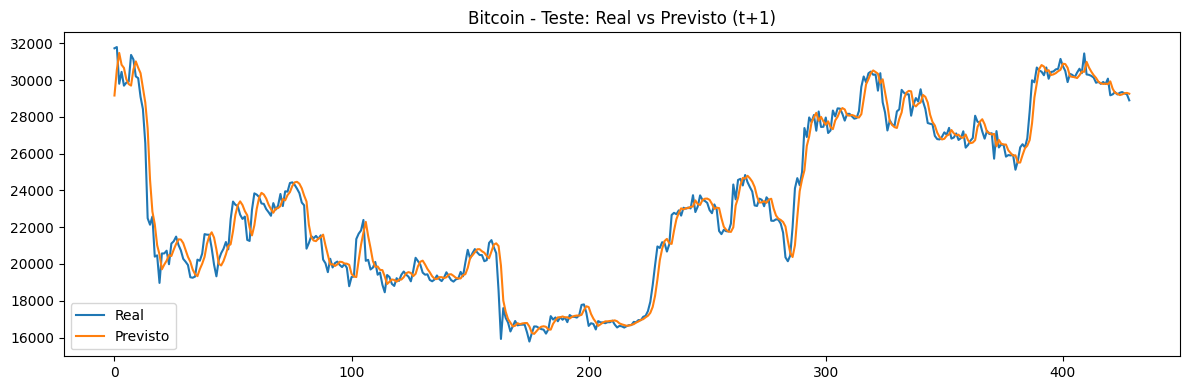

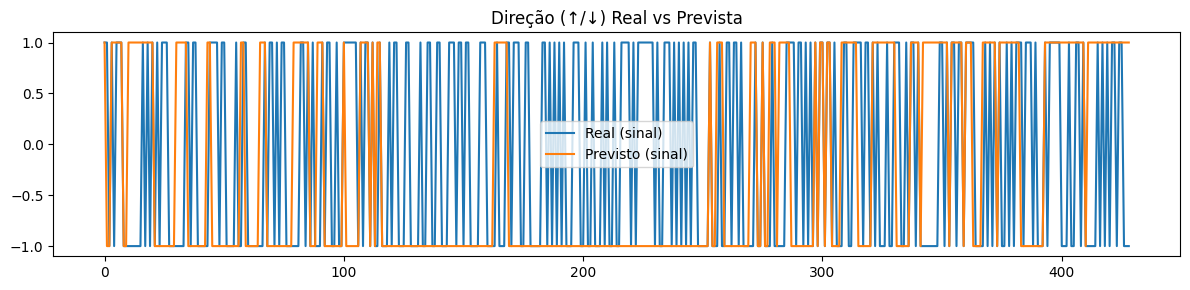

In [ ]:
#@title View
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.title("Bitcoin - Teste: Real vs Previsto (t+1)")
plt.plot(y_true, label="Real")
plt.plot(y_pred, label="Previsto")
plt.legend(); plt.tight_layout()
plt.show()

plt.figure(figsize=(12,3))
plt.title("Direção (↑/↓) Real vs Prevista")
plt.plot(real_dir, label="Real (sinal)")
plt.plot(pred_dir, label="Previsto (sinal)")
plt.legend(); plt.tight_layout()
plt.show()


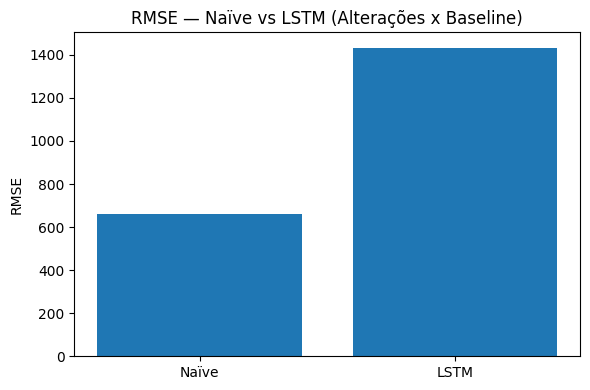

In [ ]:
plt.figure(figsize=(6,4))
plt.bar(["Naïve", "LSTM"], [rmse_nv, rmse])
plt.title("RMSE — Naïve vs LSTM (Alterações x Baseline)")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()
